In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pickle
import os, sys
import torch
from tqdm.autonotebook import tqdm
from matplotlib.lines import Line2D
from collections import defaultdict
from matplotlib.colors import LinearSegmentedColormap
# Root project
project_root = os.path.abspath(os.path.join(os.getcwd(), "../../.."))

if project_root not in sys.path:
    sys.path.append(project_root)

print("Project root added to sys.path:", project_root)

from envs import *
from basal_ganglia import *
from stn_gpe import *

# filter warnings
import warnings
warnings.filterwarnings("ignore")



plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],  # Times for publication
    "font.size": 8,                    # Base font size
    "axes.labelsize": 8,              # Axis label font size
    "axes.labelweight": "bold",
    "font.weight": "bold",   
    "axes.titlesize":8,              # Axis title (not fig title)
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize":8,              # Legend font size

    "figure.dpi": 300,                 # Display resolution
    "savefig.dpi": 300,                # Save resolution
    "figure.constrained_layout.use": True,  # Better spacing than tight_layout

    "axes.linewidth": 0.8,             # Thin but clear axes lines
    "lines.linewidth": 1.2,
    "lines.markersize": 5,

    "axes.spines.top": False,
    "axes.spines.right": False,

    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.minor.size": 2,
    "ytick.minor.size": 2,

    "legend.frameon": False,
    "legend.handlelength": 2.0,        # Slightly longer legend lines
    "legend.handletextpad": 0.5,

    "pdf.fonttype": 42,                # Embed editable fonts in PDF
    "ps.fonttype": 42
})



/var/folders/9v/hs9qlpdx4791kpqgpt09stch0000gn/T/ipykernel_22144/4162621456.py:6: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


Project root added to sys.path: /Users/charithapalika/Desktop/Lab projects/Decision Making/light_house_DBS_decision_making


# Read the params

In [2]:
yaml_path = os.path.join(project_root, 'params', 'decision_making_task_params', 'restless_bandits', 'params.yaml')
params = load_yaml(yaml_path)
STN_DATA_path = os.path.join(project_root, 'params', 'stn_gpe_params', 'params_Normal.yaml')

In [3]:
# ENV params
NUM_ARMS = params['NUM_ARMS']
MEAN_REWARD = np.array([40,40,60,80])
REW_STD = np.array([4,4,4,4])
SCALING_FACTOR = params['SCALING_FACTOR']

# Training params
TRIALS = params['TRIALS']
EPOCHS = params['EPOCHS']
BINS = params['NUM_BINS']
LR = params['LR']


LAMBDA_DECAY = 0.9836
THETA = 50
DIFFUSIVE_NOISE_MEAN = 0
DIFFUSIVE_NOISE_STD = 2.8

In [4]:
var =0.25
ARM_MONITOR = defaultdict(dict)
NUM_ARM_PICKS_MONITOR = defaultdict(dict)
DP_MONITOR = defaultdict(dict)
IP_MONITOR = defaultdict(dict)
REWARD_MONITOR = defaultdict(dict)
ARM_TRACKER = defaultdict(dict)

In [5]:
env = RestlessBanditsEnv(num_arms=NUM_ARMS, 
                         mean_reward=MEAN_REWARD/SCALING_FACTOR, 
                         std = REW_STD/SCALING_FACTOR,
                         lambda_decay = LAMBDA_DECAY, 
                         theta = THETA/SCALING_FACTOR, 
                         diffusive_noise_std = DIFFUSIVE_NOISE_STD/SCALING_FACTOR, 
                         diffusive_noise_mean = DIFFUSIVE_NOISE_MEAN/SCALING_FACTOR)

In [6]:

# ==================================================
# Choice variability and Q-value error helper functions
# ==================================================

def _to_numpy(x):
    """Convert torch tensors / arrays to numpy."""
    if hasattr(x, "detach"):
        return x.detach().cpu().numpy()
    return np.asarray(x)


def _to_scalar(x):
    """Convert tensor/array/list scalar to Python float."""
    if hasattr(x, "detach"):
        x = x.detach().cpu().numpy()
    arr = np.asarray(x)
    return float(arr.reshape(-1)[0])


def nested_defaultdict_to_dict(d):
    """Recursively convert defaultdict/dict to normal dict before pickle saving."""
    if isinstance(d, defaultdict):
        d = dict(d)
    if isinstance(d, dict):
        return {k: nested_defaultdict_to_dict(v) for k, v in d.items()}
    return d


def compute_choice_variability_metrics(arm_chosen_monitor, n_arms, window_size=15, alpha=0.7):
    """
    Computes choice variability from action sequence.

    Entropy: normalized action entropy within a rolling window.
    Switching: fraction of trial-to-trial action changes within a rolling window.
    Combined: alpha * entropy + (1 - alpha) * switching.
    """
    choices = _to_numpy(arm_chosen_monitor).astype(int)

    if choices.ndim > 2:
        choices = np.squeeze(choices)

    if choices.ndim == 1:
        choices = choices[None, :]

    epochs, trials = choices.shape
    window_size = min(window_size, trials)

    entropy_by_epoch = []
    switching_by_epoch = []
    combined_by_epoch = []

    for e in range(epochs):
        epoch_choices = choices[e]

        entropy_windows = []
        switching_windows = []
        combined_windows = []

        for start in range(0, trials - window_size + 1):
            window_choices = epoch_choices[start:start + window_size]

            counts = np.bincount(window_choices, minlength=n_arms).astype(float)
            probs = counts / np.sum(counts)
            probs_nonzero = probs[probs > 0]

            if n_arms > 1:
                entropy = -np.sum(probs_nonzero * np.log(probs_nonzero)) / np.log(n_arms)
            else:
                entropy = 0.0

            if window_size > 1:
                switching = np.mean(window_choices[1:] != window_choices[:-1])
            else:
                switching = 0.0

            combined = alpha * entropy + (1 - alpha) * switching

            entropy_windows.append(entropy)
            switching_windows.append(switching)
            combined_windows.append(combined)

        entropy_by_epoch.append(np.mean(entropy_windows))
        switching_by_epoch.append(np.mean(switching_windows))
        combined_by_epoch.append(np.mean(combined_windows))

    entropy_by_epoch = np.asarray(entropy_by_epoch)
    switching_by_epoch = np.asarray(switching_by_epoch)
    combined_by_epoch = np.asarray(combined_by_epoch)

    return {
        "window_size": window_size,
        "alpha_entropy": alpha,

        "mean_entropy": float(np.mean(entropy_by_epoch)),
        "mean_switching": float(np.mean(switching_by_epoch)),
        "mean_combined_variability": float(np.mean(combined_by_epoch)),

        "entropy_by_epoch": entropy_by_epoch,
        "switching_by_epoch": switching_by_epoch,
        "combined_variability_by_epoch": combined_by_epoch,
    }


def convert_dp_monitor_to_array(dp_monitor, num_arms):
    """
    Converts dp_monitor into shape:
        epochs x trials x arms

    Expected format in these notebooks:
        dp_monitor[arm].shape = (epochs, trials, 1)
    """
    if isinstance(dp_monitor, dict):
        q_list = []
        for arm in range(num_arms):
            if arm in dp_monitor:
                arm_key = arm
            elif np.int64(arm) in dp_monitor:
                arm_key = np.int64(arm)
            elif str(arm) in dp_monitor:
                arm_key = str(arm)
            else:
                raise KeyError(f"Arm {arm} not found in dp_monitor keys: {list(dp_monitor.keys())}")

            q_arm = _to_numpy(dp_monitor[arm_key])
            q_arm = np.squeeze(q_arm)

            if q_arm.ndim != 2:
                raise ValueError(f"Expected dp_monitor[{arm_key}] to become 2D after squeeze, got shape {q_arm.shape}")

            q_list.append(q_arm)

        q_values = np.stack(q_list, axis=-1)

    else:
        q_values = _to_numpy(dp_monitor)
        q_values = np.squeeze(q_values)

        if q_values.ndim != 3:
            raise ValueError(f"Expected dp_monitor array to be 3D, got shape {q_values.shape}")

        # If shape is arms x epochs x trials, convert to epochs x trials x arms
        if q_values.shape[0] == num_arms:
            q_values = np.transpose(q_values, (1, 2, 0))

    return q_values.astype(float)


def convert_arm_tracker_to_true_means(arm_tracker_full, num_arms, trials):
    """
    Converts restless-bandit arm_tracker_full into true reward means.

    Output shape:
        epochs x trials x arms

    arm_tracker_full[epoch][trial][arm][0] contains the true mean reward
    on the same normalized scale used by the environment.
    """
    n_epochs = len(arm_tracker_full)
    true_means = np.full((n_epochs, trials, num_arms), np.nan, dtype=float)

    for e in range(n_epochs):
        epoch_tracker = arm_tracker_full[e]
        n_t = min(trials, len(epoch_tracker))

        for t in range(n_t):
            arm_dict = epoch_tracker[t]

            for arm in range(num_arms):
                if arm in arm_dict:
                    arm_key = arm
                elif np.int64(arm) in arm_dict:
                    arm_key = np.int64(arm)
                elif str(arm) in arm_dict:
                    arm_key = str(arm)
                else:
                    continue

                true_means[e, t, arm] = _to_scalar(arm_dict[arm_key][0])

    return true_means


def compute_q_error_metrics(dp_monitor, true_means, arm_chosen_monitor=None, num_arms=None):
    """
    Computes DP/Q-value error by comparing dp_monitor to true restless-bandit means.

    dp_monitor is converted to:
        epochs x trials x arms

    true_means should be:
        epochs x trials x arms
    """
    if num_arms is None:
        num_arms = true_means.shape[-1]

    q_values = convert_dp_monitor_to_array(dp_monitor, num_arms=num_arms)
    true_means = np.asarray(true_means, dtype=float)

    min_epochs = min(q_values.shape[0], true_means.shape[0])
    min_trials = min(q_values.shape[1], true_means.shape[1])

    q_values = q_values[:min_epochs, :min_trials, :]
    true_means = true_means[:min_epochs, :min_trials, :]

    q_error = q_values - true_means

    rmse_by_epoch = np.sqrt(np.nanmean(q_error ** 2, axis=(1, 2)))
    mae_by_epoch = np.nanmean(np.abs(q_error), axis=(1, 2))

    metrics = {
        "mean_q_rmse": float(np.nanmean(rmse_by_epoch)),
        "mean_q_mae": float(np.nanmean(mae_by_epoch)),
        "q_rmse_by_epoch": rmse_by_epoch,
        "q_mae_by_epoch": mae_by_epoch,
    }

    if arm_chosen_monitor is not None:
        choices = _to_numpy(arm_chosen_monitor).astype(int)
        if choices.ndim > 2:
            choices = np.squeeze(choices)
        if choices.ndim == 1:
            choices = choices[None, :]

        choices = choices[:min_epochs, :min_trials]

        selected_errors = []
        for e in range(min_epochs):
            for t in range(min_trials):
                chosen_arm = int(choices[e, t])
                if 0 <= chosen_arm < q_values.shape[-1]:
                    selected_errors.append(abs(q_values[e, t, chosen_arm] - true_means[e, t, chosen_arm]))

        metrics["mean_selected_abs_value_error"] = float(np.nanmean(selected_errors))

    return metrics


In [7]:

# ==================================================
# Single-run labels and save path
# ==================================================

CONDITION_NAME = "Normal"
DEL_LIM_CURRENT = None

metrics_file_name = "restless_bandits_choice_q_metrics_normal.pkl"

METRICS_SAVE_FILE = os.path.join(
    project_root,
    "simulations",
    "decision_making_tasks",
    "restless_bandits",
    metrics_file_name
)


# Simulate Restless bandits

In [8]:
reward_monitor, arm_chosen_monitor, avg_counts,ip_monitor, dp_monitor,ep_monitor, arm_tracker_full= train(env, 
                                                      trails = TRIALS, 
                                                      epochs = EPOCHS, 
                                                      lr = LR, 
                                                      bins = BINS,
                                                      STN_data = STN_DATA_path,
                                                      d1_amp=1,
                                                      d2_amp=0.0035, #0.00325, 
                                                      gpi_threshold=0.3,
                                                      max_gpi_iters=50,
                                                      del_lim=DEL_LIM_CURRENT, train_IP = False, 
                                                      del_med = None, printing = False,
                                                      gpi_mean= 1, ep_0 = 0.4,
                                                      alpha_ep = 0.0,
                                                      eta_ep = 0.1,
                                                      baseline_ep = 0.0, 
                                                      track_arms = True)


Running STN-GPe system


  0%|          | 0/50000 [00:00<?, ?it/s]

StdDev of STN: 0.3150835525808694, Mean of STN: 1.0


  0%|          | 0/25 [00:00<?, ?it/s]

In [9]:

# ==================================================
# Compute and save choice-variability and Q-error metrics for current single run
# ==================================================

TRUE_MEAN_REWARDS = convert_arm_tracker_to_true_means(
    arm_tracker_full=arm_tracker_full,
    num_arms=NUM_ARMS,
    trials=TRIALS
)

choice_var_metrics = compute_choice_variability_metrics(
    arm_chosen_monitor=arm_chosen_monitor,
    n_arms=NUM_ARMS,
    window_size=15,
    alpha=0.7
)

q_error_metrics = compute_q_error_metrics(
    dp_monitor=dp_monitor,
    true_means=TRUE_MEAN_REWARDS,
    arm_chosen_monitor=arm_chosen_monitor,
    num_arms=NUM_ARMS
)


def get_del_lim_key(del_lim_current):
    if del_lim_current is None:
        return "no_limit"
    return float(del_lim_current)


if DEL_LIM_CURRENT is None:
    del_lim_key = "no_limit"
    del_lim_label = "No limit"
else:
    del_lim_key = float(DEL_LIM_CURRENT)
    del_lim_label = str(DEL_LIM_CURRENT)

metrics_data = {
    "CONDITION_NAME": CONDITION_NAME,
    "DEL_LIM_CURRENT": DEL_LIM_CURRENT,
    "DEL_LIM_KEY": del_lim_key,
    "DEL_LIM_LABEL": del_lim_label,

    "SCALING_FACTOR": SCALING_FACTOR,
    "NUM_ARMS": NUM_ARMS,
    "TRIALS": TRIALS,
    "EPOCHS": EPOCHS,
    "BINS": BINS,
    "LAMBDA_DECAY": LAMBDA_DECAY,
    "THETA": THETA,
    "DIFFUSIVE_NOISE_MEAN": DIFFUSIVE_NOISE_MEAN,
    "DIFFUSIVE_NOISE_STD": DIFFUSIVE_NOISE_STD,

    # Main required metrics
    "entropy_plus_switching": choice_var_metrics["mean_combined_variability"],
    "q_error": q_error_metrics["mean_q_rmse"],

    # Components
    "entropy": choice_var_metrics["mean_entropy"],
    "switching": choice_var_metrics["mean_switching"],

    # Optional Q details
    "q_rmse": q_error_metrics["mean_q_rmse"],
    "q_mae": q_error_metrics["mean_q_mae"],
    "selected_value_error": q_error_metrics.get("mean_selected_abs_value_error", None),

    # Raw monitors for checking / replotting if needed
    "ARM_MONITOR": arm_chosen_monitor,
    "DP_MONITOR": dp_monitor,
    "REWARD_MONITOR": reward_monitor,
    "TRUE_MEAN_REWARDS": TRUE_MEAN_REWARDS,
}

os.makedirs(os.path.dirname(METRICS_SAVE_FILE), exist_ok=True)

with open(METRICS_SAVE_FILE, "wb") as f:
    pickle.dump(metrics_data, f)

print("Saved current restless-bandit single-run metrics")
print("------------------------------------------------")
print(f"File: {METRICS_SAVE_FILE}")
print(f"Condition: {metrics_data['CONDITION_NAME']}")
print(f"Delta limit: {metrics_data['DEL_LIM_LABEL']}")
print(f"Entropy + switching = {metrics_data['entropy_plus_switching']:.4f}")
print(f"Q-value error       = {metrics_data['q_error']:.4f}")
print(f"Entropy             = {metrics_data['entropy']:.4f}")
print(f"Switching           = {metrics_data['switching']:.4f}")


Saved current restless-bandit single-run metrics
------------------------------------------------
File: /Users/charithapalika/Desktop/Lab projects/Decision Making/light_house_DBS_decision_making/simulations/decision_making_tasks/restless_bandits/restless_bandits_choice_q_metrics_normal.pkl
Condition: Normal
Delta limit: No limit
Entropy + switching = 0.2347
Q-value error       = 0.1371
Entropy             = 0.2698
Switching           = 0.1528


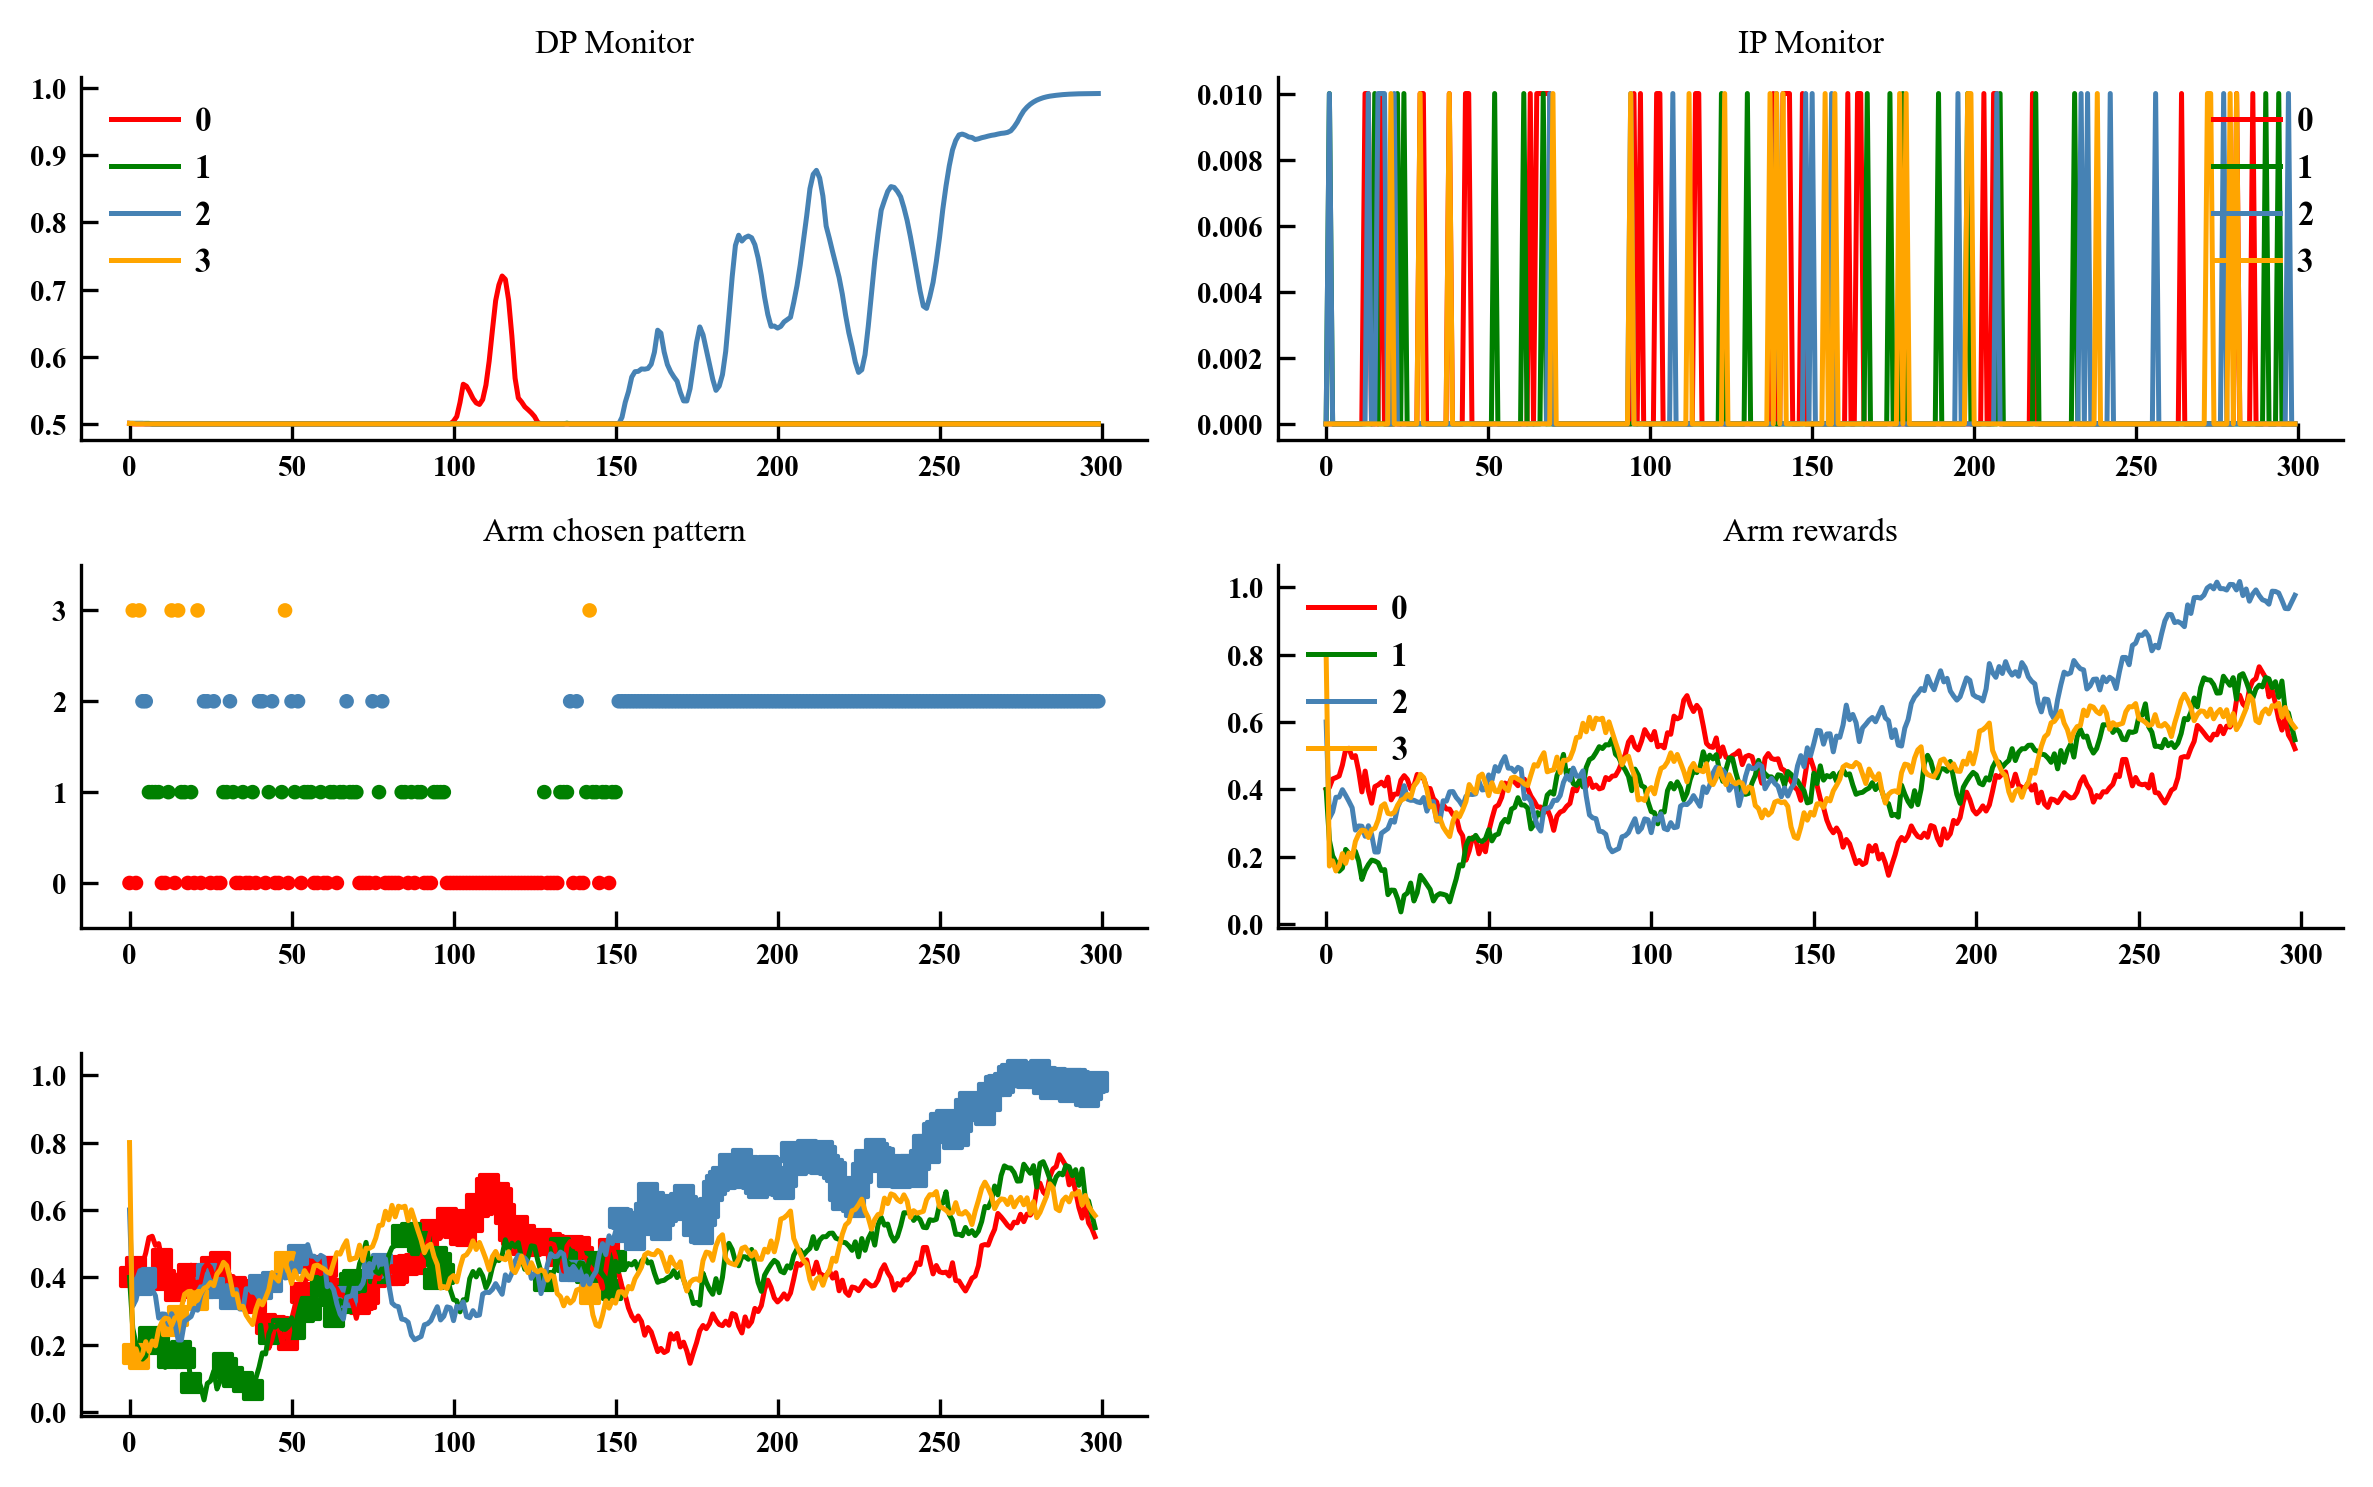

In [10]:
ARM_MONITOR[var] = arm_chosen_monitor
REWARD_MONITOR[var] = reward_monitor
DP_MONITOR[var] = dp_monitor
IP_MONITOR[var] = ip_monitor
ARM_TRACKER[var] = arm_tracker_full


EPOCH_NUM = 24
color_map = {0: 'Red', 1: 'green', 2: 'steelblue', 3: 'orange'}
plt.figure(figsize=(8,5))
plt.subplot(321)
for i in range(NUM_ARMS):
    plt.plot(DP_MONITOR[var][i][EPOCH_NUM].squeeze().detach().numpy(), color = color_map[i], label = i)
    plt.legend()  
plt.title('DP Monitor')
plt.subplot(322)
for i in range(NUM_ARMS):
    plt.plot(IP_MONITOR[var][i][EPOCH_NUM].squeeze().detach().numpy(), color = color_map[i], label = i)
    plt.legend() 
plt.title('IP Monitor')

plt.subplot(323)
values = ARM_MONITOR[var][EPOCH_NUM]
color_array = np.vectorize(color_map.get)(values)
plt.scatter(np.arange(TRIALS),values, marker = '.', color = color_array)
plt.ylim(-0.5,3.5)
plt.title('Arm chosen pattern')

plt.subplot(324)
arm_means = ARM_TRACKER[var][EPOCH_NUM]
REW_ARRAY = np.zeros((NUM_ARMS, len(arm_means)))
for i in range(len(arm_means)):
    arms = arm_means[i]
    rews = np.array([arms[0][0], arms[1][0], arms[2][0], arms[3][0]])
    REW_ARRAY[:,i] = rews
for i in range(NUM_ARMS):
    plt.plot(REW_ARRAY[i][0:-2], color = color_map[i], label = i)
plt.title('Arm rewards')
plt.legend()


plt.subplot(325)
MODIFIED_REW_ARRAY = np.zeros((NUM_ARMS,TRIALS))
for i in range(TRIALS):
    arm = int(ARM_MONITOR[var][EPOCH_NUM][i].detach().numpy())
    MODIFIED_REW_ARRAY[arm,i] = REW_ARRAY[arm,i] 
for i in range(NUM_ARMS):
    plt.plot(REW_ARRAY[i][0:-2], color = color_map[i], label = i)

    non_zero_indices = MODIFIED_REW_ARRAY[i] !=0
    time = np.arange(TRIALS)
    filtered_time = time[non_zero_indices]
    filtered_rewards = MODIFIED_REW_ARRAY[i][non_zero_indices]
    plt.scatter(filtered_time,filtered_rewards, color = color_map[i], marker = 's', s = 20)
plt.tight_layout()

Text(0, 0.5, '$P(Best Arm)$')

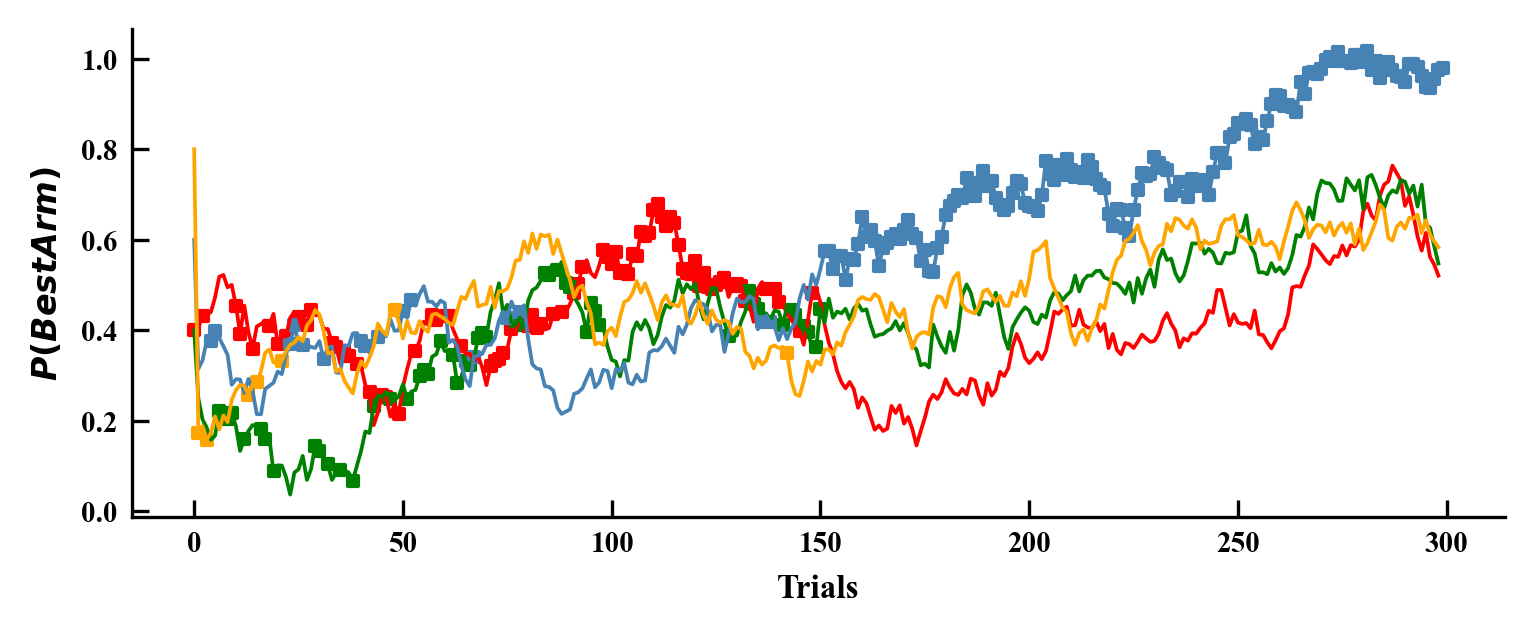

In [11]:
color_map = {0: 'Red', 1: 'green', 2: 'steelblue', 3: 'orange'}
MODIFIED_REW_ARRAY = np.zeros((NUM_ARMS,TRIALS))
for i in range(TRIALS):
    arm = int(ARM_MONITOR[var][EPOCH_NUM][i].detach().numpy())
    MODIFIED_REW_ARRAY[arm,i] = REW_ARRAY[arm,i]

plt.figure(figsize = (5,2))    
for i in range(NUM_ARMS):
    plt.plot(REW_ARRAY[i][0:-2], color = color_map[i], label = i, linewidth = 0.9)

    non_zero_indices = MODIFIED_REW_ARRAY[i] !=0
    time = np.arange(TRIALS)
    filtered_time = time[non_zero_indices]
    filtered_rewards = MODIFIED_REW_ARRAY[i][non_zero_indices]
    plt.scatter(filtered_time,filtered_rewards, color = color_map[i], marker = 's', s = 5)
plt.xlabel('Trials')
plt.ylabel('$P(Best Arm)$')
# plt.title('Reward of the arm and choices of arm picking')

In [12]:
# Calculate average Prob of best arm picking every bin
def max_rew_arm(x:dict):
    rew_list = np.array([x[key][0] for key in list(x.keys())])
    return np.argmax(rew_list)

def process_epoch_optimal_arm(x:list):
    optimal_arm = [max_rew_arm(x[trail]) for trail in range(len(x)-1)]
    return optimal_arm

In [13]:
OPTIMAL_CHOICE_ARRAY = np.array([process_epoch_optimal_arm(ARM_TRACKER[var][epoch]) for epoch in range(len(ARM_TRACKER[var]))])
ACTUAL_CHOICE_ARRAY = np.array(ARM_MONITOR[var])
NUMBER_OF_MATCHES = (OPTIMAL_CHOICE_ARRAY == ACTUAL_CHOICE_ARRAY)*1
PROB = np.mean(NUMBER_OF_MATCHES,axis = 1)
print(f'P(Best Arm) = {PROB}')
print(f'Average P(Best arm) = {np.mean(PROB)}')

P(Best Arm) = [0.46666667 0.55       0.46666667 0.5        0.30333333 0.40666667
 0.66       0.51       0.65       0.49333333 0.76333333 0.39
 0.57666667 0.67333333 0.7        0.63333333 0.5        0.67
 0.73666667 0.44       0.50666667 0.64       0.74       0.44333333
 0.69666667]
Average P(Best arm) = 0.5646666666666667
